## Hausaufgabe 1

### Autarkes Energienetz

.<div style="width:50%; margin: 0 auto;">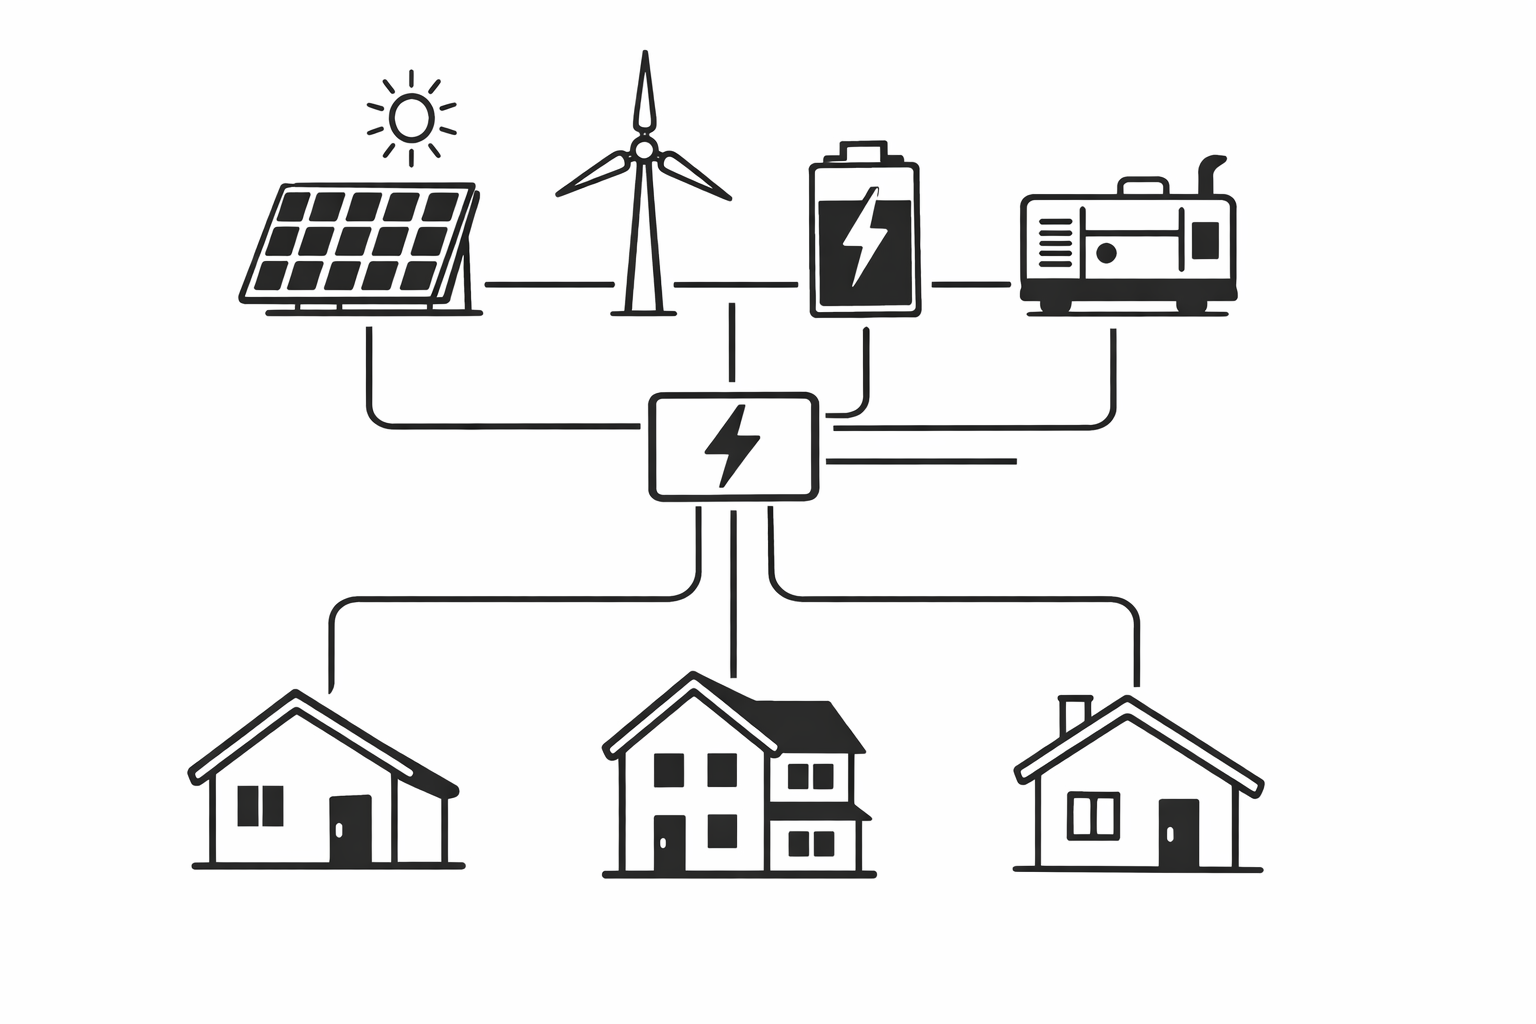</div>

Sie sind Teil eines Ingenieurteams, das mit der Planung eines nachhaltigen autarken Mikronetzes für eine kleine Gemeinde beauftragt ist. Die Gemeinde hat keinen Anschluss an ein zentrales Energienetz und muss ihren gesamten Energiebedarf selber decken. Das Mikronetz muss die von Solarmodulen, Windkraftanlagen, einem Batteriesystem und einem Dieselgenerator erzeugte Energie effizient verteilen, um den täglichen Energiebedarf der Gemeinde zu decken. Ihr Ziel ist es, die Zuweisung der Ressourcen (Solar, Wind, Batterie, Diesel) so zu verbessern, dass die Kosten verringert werden und gleichzeitig die Versorgungssicherheit gewährleistet ist.

Das Netz hat folgende Funktionsweise (bitte sorgfältige jeden Punkt lesen und verstehen):
- erzeugte Solar- und Windenergie werden soweit nötig direkt zur Deckung des Bedarfs verwendet
- wird mehr Solar- und Windenergie erzeugt, als Bedarf besteht, wird zuerst der überschüssige Anteil der Windenergie zum Laden der Batterie eingesetzt
- wird allein mehr Solarenergie erzeugt, als Bedarf besteht, wird der überschüssige Anteil ebenfalls zum Laden der Batterie eingesetzt
- eine Energiemenge von 1 kWh lädt die Batterie um 0.9 kWh auf
- hat die Batterie die maximal mögliche Energiemenge gespeichert, kann nicht weiter geladen werden und die überschüssige erzeugte Energie kann nicht genutzt werden 
- wird weniger Energie erzeugt, als Bedarf besteht, wird die restliche benötigte Energie von der Batterie bereitgestellt
- ist die Batterie vollständig entladen, springt der Dieselgenerator an und liefert die restliche benötigte Energie

Pro **verbrauchter** kWh entstehen unterschiedliche Kosten, die im unten angegebenen Python-Dictionary enthalten sind. Für das Aufladen der Batterie werden zunächst keine Kosten berechnet. Diese werden erst später beim Entladen der Batterie berücksichtigt. Die unter 'batterie' angegebenen Kosten beziehen sich auf das Entladen der Batterie.

Als Grundlage dienen außerdem (beispielhafte) Daten über die stündliche Erzeugung und den stündlichen Bedarf über einen Zeitraum von 24 Stunden (In der Praxis würde das natürlich nicht ausreichen und man müsste einen größeren Zeitraum betrachten.). Gehen Sie bitte davon aus, dass die Daten für jeden Tag in derselben Form zutreffen.

1. Berechnen Sie zunächst die Differenz zwischen gesamter Erzeugung durch Solar und Wind und gesamtem Bedarf pro Tag und geben Sie diese aus! (Beispielausgabe: "Es werden 4 kWh mehr Energie pro Tag erzeugt als Bedarf besteht." )
2. Ermitteln Sie die Anzahl der Stunden, in denen an jedem Tag der Bedarf größer als die Erzeugung ist! (Beispielausgabe: "Während insgesamt 3 Stunden ist der Bedarf größer als die Erzeugung.")


In [26]:
# stündliche Erzeugung  (kWh)
solar24 = [0, 0, 0, 0, 0, 1, 3, 5, 7, 8, 10, 12, 11, 9, 7, 4, 2, 1, 0, 0, 0, 0, 0, 0]
wind24 = [1, 3, 4, 5, 6, 5, 4, 4, 6, 7, 8, 7, 5, 6, 5, 4, 3, 0, 1, 3, 4, 3, 2, 2]
# stündlicher Bedarf (kWh)
bedarf24 = [5, 5, 4, 4, 5, 7, 7, 8, 9, 6, 9, 10, 10, 9, 8, 8, 7, 10, 5, 5, 6, 7, 6, 5]
# kosten in Euro pro kWh
kostenkWh = {
    'solar': 0.08,
    'wind': 0.11,
    'batterie': 0.13,
    'diesel': 0.30
}
# Hier eigenen Code schreiben

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt



Strom_erzeugt_24 = np.array(solar24) + np.array(wind24)
Strom_Differenz_24 = Strom_erzeugt_24 - np.array(bedarf24)
Strom_Differenz_Tag = Strom_Differenz_24.sum()
print(f'Es werden {Strom_Differenz_Tag} kWh mehr Energie pro Tag erzeugt als Bedarf besteht')
Stunden_negativ = len([x for x in Strom_Differenz_24 if x < 0])
print(f'Während insgesamt {Stunden_negativ} Stunden ist der Bedarf größer als die Erzeugung')


Es werden 13 kWh mehr Energie pro Tag erzeugt als Bedarf besteht
Während insgesamt 11 Stunden ist der Bedarf größer als die Erzeugung


Nun soll simuliert werden, wie sich der Ladezustand der Batterie über den Tag ändert. Dazu werden Erzeugung und Bedarf nacheinander für jede Stunde untersucht, und entsprechend die Batterie geladen oder entladen oder der Dieselgenerator verwendet. Für jede Stunde sollen außerdem die Kosten berechnet werden. Zu Beginn des Tages sei die Batterie **vollständig entladen** (Ladezustand = 0 kWh).

Für jede Stunde soll der Ladezustand 'grafisch' dargestellt werden. Dazu wird die Uhrzeit (Stunde) ausgegeben, gefolgt von einem horizontalen Balken aus so vielen '#' Zeichen, wie kWh in der Batterie gespeichert sind. Beispiel für 7 Uhr und 8 kWh:
`07: ########` .  24 solcher Zeilen müssen untereinander dargestellt werden.

Am Ende des Tages soll folgendes in einer Textmeldung ausgegeben werden:
- der Ladezustand der Batterie (wie viele kWh sind gespeichert),
- der maximal erreichte Ladezustand (wie viele kWh waren maximal gespeichert),
- die wie viele Stunden der Dieselgenerator in Betrieb war
- die insgesamt entstandenen Kosten. 

Es wird zunächst eine Batteriekapazität von 20 kWh angenommen

Lösungshinweis: aus der oben gegeben Funktionsweise gibt es vier verschiedene Möglichkeiten bezüglich der Ladung und Entladung der Batterie und des Betriebs des Generators. Schreiben Sie eine Schleife über 24 h und unterscheiden Sie die vier Fälle innerhalb der Schleife.

In [27]:
batt_kap = 20  # maximale Batteriekapazität in kWh

# --- Startzustand ---
batt_ladung           = 0
Generator_stunden_counter = 0
kosten24              = np.zeros(24)
batt_ladung24         = np.zeros(24)
Generator_Betrieb     = np.zeros(24)


# --- Stundensimulation ---
for i in range(24):
    # Ladezustand zu Beginn der Stunde speichern und anzeigen
    batt_ladung24[i] = batt_ladung
    print(f'{i:02d}: {int(batt_ladung) * "#"}')

    # Fall 1: Erzeugung deckt den Bedarf – Überschuss lädt die Batterie
    if bedarf24[i] <= Strom_erzeugt_24[i]:
        batt_ladung += 0.9 * Strom_Differenz_24[i]
        batt_ladung = min(batt_ladung, batt_kap)        # Kapazitätsgrenze

        if bedarf24[i] <= solar24[i]:                   # Solar allein reicht
            kosten24[i] = bedarf24[i] * kostenkWh['solar']
        else:                                            # Solar + Wind nötig
            kosten24[i] = (solar24[i] * kostenkWh['solar']
                         + (bedarf24[i] - solar24[i]) * kostenkWh['wind'])

    # Fall 2: Erzeugung reicht nicht – Batterie oder Generator springt ein
    else:
        fehlende_energie = -Strom_Differenz_24[i]       # wie viel fehlt (positiv)

        if batt_ladung >= fehlende_energie:              # Batterie reicht aus
            batt_ladung -= fehlende_energie
            kosten24[i] = (solar24[i]       * kostenkWh['solar']
                         + wind24[i]        * kostenkWh['wind']
                         + fehlende_energie * kostenkWh['batterie'])

        else:                                            # Batterie leer → Diesel
            diesel_energie = fehlende_energie - batt_ladung
            Generator_Betrieb[i] = diesel_energie
            Generator_stunden_counter += 1
            kosten24[i] = (solar24[i]      * kostenkWh['solar']
                         + wind24[i]       * kostenkWh['wind']
                         + batt_ladung     * kostenkWh['batterie']
                         + diesel_energie  * kostenkWh['diesel'])
            batt_ladung = 0

# --- Tagesergebnis ---
kosten   = kosten24.sum()
batt_max = max(batt_ladung24.max(), batt_ladung)
print(f'Ladezustand der Batterie:  {batt_ladung:.1f} kWh')
print(f'Maximaler Ladezustand:     {batt_max:.1f} kWh')
print(f'Dieselgenerator lief       {Generator_stunden_counter} Stunden')
print(f'Gesamtkosten:              {kosten:.2f} €')


00: 
01: 
02: 
03: 
04: 
05: #
06: 
07: 
08: #
09: #####
10: #############
11: ####################
12: ####################
13: ####################
14: ####################
15: ####################
16: ####################
17: ##################
18: #########
19: #####
20: ###
21: #
22: 
23: 
Ladezustand der Batterie:  0.0 kWh
Maximaler Ladezustand:     20.0 kWh
Dieselgenerator lief       5 Stunden
Gesamtkosten:              19.39 €


Zur Inbetriebnahme ist die Batterie vollständig entladen. Am Ende des ersten Tages könnte sie ja nach Kapazität unter Umständen einen höheren Ladezustand aufweisen und am Ende des zweiten Tages einen noch höheren. Damit bei der Planung der Normalzustand berücksichtigt wird, sollen sieben aufeinander folgende Tage (mit identischen Bedingungen) simuliert werden.

Die Ausgabe der Ergebnisse soll jeweils nur **für den letzten Tag** erfolgen. Außerdem soll die gesamte Simulation mehrfach mit unterschiedlichen Batteriekapazitäten durchgeführt werden. Diese soll deshalb auch mit ausgegeben werden. Die Ausgabe soll diesmal in einer Tabelle mit 5 Spalten erfolgen (Batteriekapazität, Ladezustand, max. Ladung, Dieselgenerator, Kosten pro Stunde). Jede Spalte soll 15 Zeichen breit sein.


In [28]:
liste_batt_kap = [20, 25, 30, 35, 40, 45, 50]

# --- Hilfsfunktion: simuliert einen Tag ---
def simuliere_tag(batt_kap, batt_ladung_start):
    batt_ladung               = batt_ladung_start   # Startzustand von außen übergeben
    Generator_stunden_counter = 0
    kosten24                  = np.zeros(24)
    batt_ladung24             = np.zeros(24)

    for i in range(24):
        batt_ladung24[i] = batt_ladung

        # Fall 1: Erzeugung deckt den Bedarf – Überschuss lädt die Batterie
        if bedarf24[i] <= Strom_erzeugt_24[i]:
            batt_ladung += 0.9 * Strom_Differenz_24[i]
            batt_ladung = min(batt_ladung, batt_kap)

            if bedarf24[i] <= solar24[i]:               # Solar allein reicht
                kosten24[i] = bedarf24[i] * kostenkWh['solar']
            else:                                        # Solar + Wind nötig
                kosten24[i] = (solar24[i] * kostenkWh['solar']
                             + (bedarf24[i] - solar24[i]) * kostenkWh['wind'])

        # Fall 2: Erzeugung reicht nicht – Batterie oder Generator springt ein
        else:
            fehlende_energie = -Strom_Differenz_24[i]

            if batt_ladung >= fehlende_energie:          # Batterie reicht aus
                batt_ladung -= fehlende_energie
                kosten24[i] = (solar24[i]       * kostenkWh['solar']
                             + wind24[i]        * kostenkWh['wind']
                             + fehlende_energie * kostenkWh['batterie'])
            else:                                        # Batterie leer → Diesel
                diesel_energie = fehlende_energie - batt_ladung
                Generator_stunden_counter += 1
                kosten24[i] = (solar24[i]     * kostenkWh['solar']
                             + wind24[i]      * kostenkWh['wind']
                             + batt_ladung    * kostenkWh['batterie']
                             + diesel_energie * kostenkWh['diesel'])
                batt_ladung = 0

    kosten   = kosten24.sum()
    batt_max = max(batt_ladung24.max(), batt_ladung)
    return batt_ladung, batt_max, Generator_stunden_counter, kosten


# --- Tabellenkopf ---
print(f'{"Batteriekapaz.":>15} {"Ladezustand":>15} {"max. Ladung":>15} {"Dieselgenerator":>15} {"Kosten/Stunde":>15}')
print('-' * 75)

# --- 7 Tage für jede Batteriegröße simulieren, nur Tag 7 ausgeben ---
for k in liste_batt_kap:
    batt_ladung = 0
    for tag in range(7):
        batt_ladung, batt_max, diesel_h, kosten = simuliere_tag(k, batt_ladung)

    print(f'{k:>15} {batt_ladung:>15.1f} {batt_max:>15.1f} {diesel_h:>15} {kosten/24:>15.2f}')


 Batteriekapaz.     Ladezustand     max. Ladung Dieselgenerator   Kosten/Stunde
---------------------------------------------------------------------------
             20             0.0            20.0               5            0.81
             25             0.0            25.0               4            0.77
             30             0.0            30.0               2            0.74
             35             5.0            35.0               1            0.70
             40            10.0            40.0               0            0.69
             45            15.0            45.0               0            0.69
             50            20.0            50.0               0            0.69


Das berechnete Ergebnis zeigt, welche Batteriekapazität benötigt wird, damit kein teurer durch den Dieselgenerator erzeugter Strom benötigt wird. Mit der programmierten Simulation lassen sich nun viele weitere Szenarien durchspielen. Beispiele dafür sind:

- Was passiert, wenn statt der Batterie die Erzeugungskapazität von Windkraft oder Solar vergrößert wird?
- Was ändert sich, wenn für jeden Tag andere zeitabhängige Verhältnisse von Erzeugung und Bedarf betrachtet werden und ein langer Zeitraum modelliert wird?
- Alle Energieliefersystem und auch die Batterie erfordern Investitionen, die dann über den Energiepreis abgeschrieben werden müssen. Diese Kosten könnten in die Betrachtung mit aufgenommen werden.

Im Rahmen dieser Hausaufgabe ist das alles nicht gefordert, Sie können es aber natürlich ausprobieren. 